In [ ]:
import numpy as np
import cv2 as cv2
import matplotlib.pyplot as plt
import pandas as pd

## LIBRARY

Library numpy untuk operasi numerik dan manipulasi array citra, cv2 untuk pemrosesan citra digital, matplotlib.pyplot untuk visualisasi citra dan histogram, serta pandas untuk pengolahan data, yang secara keseluruhan menjadi dasar dalam pengolahan citra digital terutama dalam manipulasi piksel dan analisis data.

## MENAMPILKAN CITRA

Kode digunakan untuk membaca gambar `Meledak.PNG` menggunakan `plt.imread()`. 

Setelah gambar berhasil dibaca, citra ditampilkan menggunakan `plt.imshow()`. Fungsi `plt.axis('on')` digunakan agar sumbu koordinat tetap terlihat pada tampilan gambar.

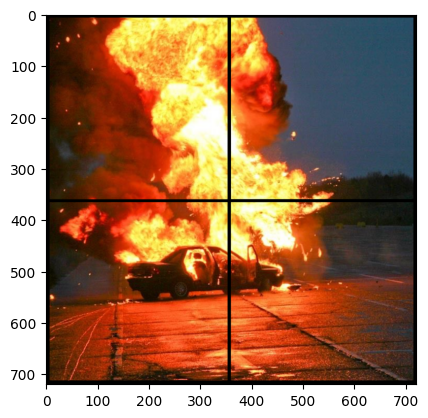

In [7]:
Meledak = plt.imread("Assets/Meledak.PNG")

plt.imshow(Meledak)
plt.axis('on')
plt.show()

## SLICING

Kode diawali dengan membaca gambar `Meledak.PNG` menggunakan `plt.imread()`. Setelah itu, ukuran gambar diambil untuk mendapatkan tinggi, lebar, dan jumlah channel citra.

Titik tengah gambar dihitung menggunakan pembagian integer (`//`) agar citra dapat dibagi menjadi 4 bagian.

Variabel `gap` digunakan untuk memberi jarak pada bagian tengah gambar agar garis pemisah tidak ikut terambil, sedangkan `crop` digunakan untuk memotong sedikit bagian tepi luar gambar.

Citra kemudian dibagi menjadi 4 bagian menggunakan teknik slicing:

- `part1` → kiri atas
- `part2` → kanan atas
- `part3` → kiri bawah
- `part4` → kanan bawah

Setelah proses slicing selesai, keempat bagian citra ditampilkan menggunakan `subplot` dengan susunan 2×2.

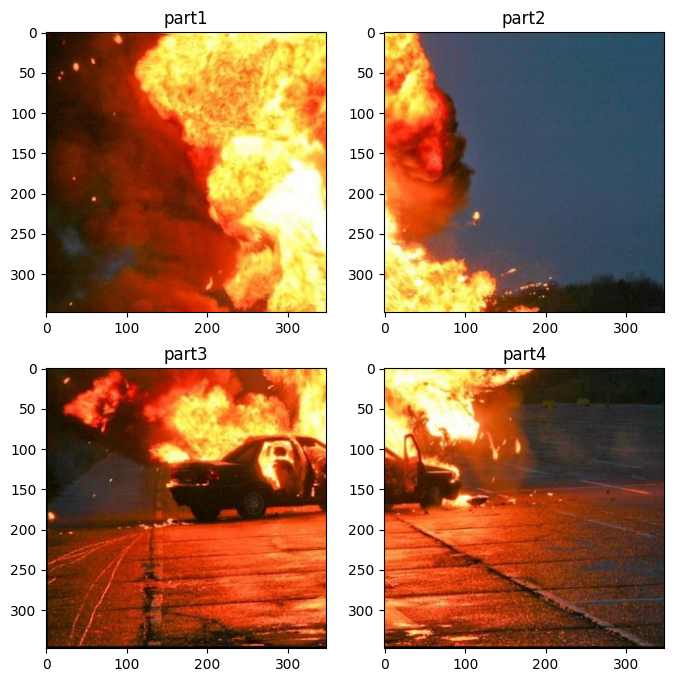

In [ ]:
Meledak = plt.imread("Assets/Meledak.PNG")

tinggi, lebar, channel = Meledak.shape

tengah_tinggi = tinggi // 2
tengah_lebar  = lebar // 2

gap = 7
crop = 5

part1 = Meledak[
    crop:tengah_tinggi-gap,
    crop:tengah_lebar-gap
]

part2 = Meledak[
    crop:tengah_tinggi-gap,
    tengah_lebar+gap:lebar-crop
]

part3 = Meledak[
    tengah_tinggi+gap:tinggi-crop,
    crop:tengah_lebar-gap
]

part4 = Meledak[
    tengah_tinggi+gap:tinggi-crop,
    tengah_lebar+gap:lebar-crop
]

plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
plt.imshow(part1)
plt.title("part1")

plt.subplot(2,2,2)
plt.imshow(part2)
plt.title("part2")

plt.subplot(2,2,3)
plt.imshow(part3)
plt.title("part3")

plt.subplot(2,2,4)
plt.imshow(part4)
plt.title("part4")

plt.show()

## PENGGABUNGAN

Kode digunakan untuk menggabungkan kembali empat bagian citra (`part1`, `part2`, `part3`, dan `part4`) menjadi satu gambar utuh.

Ukuran citra baru ditentukan berdasarkan jumlah tinggi dan lebar dari bagian-bagian citra. Selanjutnya dibuat array kosong menggunakan `np.zeros()` sebagai tempat penyimpanan hasil gabungan.

Proses penggabungan dilakukan menggunakan perulangan `for` untuk menyalin setiap piksel dari masing-masing bagian citra ke posisi yang sesuai pada array `gabung`.

- `part1` ditempatkan di kiri atas
- `part2` di kanan atas
- `part3` di kiri bawah
- `part4` di kanan bawah

Setelah semua bagian digabungkan, hasil citra ditampilkan menggunakan `plt.imshow()`.

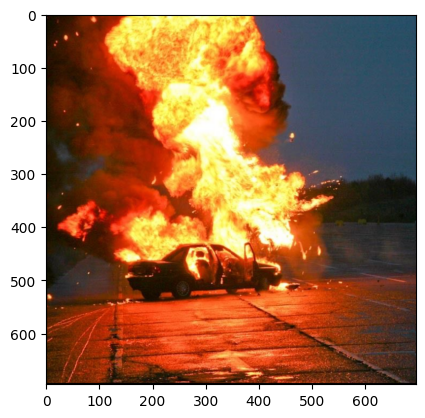

In [43]:
tinggi_baru = len(part1) + len(part3)
lebar_baru = len(part1[0]) + len(part2[0])

gabung = np.zeros((tinggi_baru, lebar_baru, 3))

# part1
for y in range(len(part1)):
    for x in range(len(part1[0])):
        gabung[y][x] = part1[y][x]

# part2
for y in range(len(part2)):
    for x in range(len(part2[0])):
        gabung[y][x + len(part1[0])] = part2[y][x]

# part3
for y in range(len(part3)):
    for x in range(len(part3[0])):
        gabung[y + len(part1)][x] = part3[y][x]

# part4
for y in range(len(part4)):
    for x in range(len(part4[0])):
        gabung[y + len(part1)][x + len(part1[0])] = part4[y][x]

plt.imshow(gabung)
plt.axis('on')
plt.show()

## EQUALIZATION

Citra hasil penggabungan terlebih dahulu diubah menjadi grayscale menggunakan `cv2.cvtColor()`. Nilai piksel kemudian dikonversi ke rentang 0–255 agar sesuai untuk proses histogram equalization.

Fungsi `ekualisasi()` dibuat untuk melakukan histogram equalization secara manual. 

Tahapan yang dilakukan pada fungsi ini meliputi:

- menghitung histogram citra,
- menghitung nilai Cumulative Distribution Function (CDF),
- melakukan normalisasi CDF,
- mengganti nilai piksel berdasarkan hasil normalisasi.

Tujuan histogram equalization adalah untuk meningkatkan kontras citra agar distribusi intensitas piksel menjadi lebih merata.

Hasil akhir ekualisasi kemudian ditampilkan dalam bentuk citra grayscale menggunakan `plt.imshow()`.

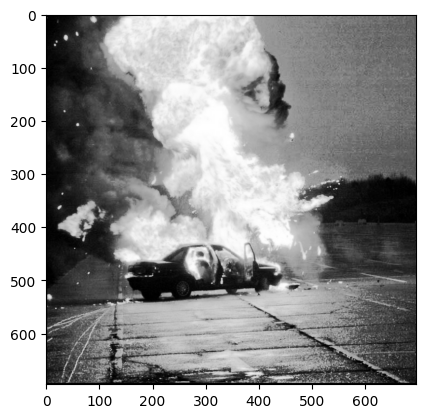

In [ ]:
gray = cv2.cvtColor(gabung.astype('float32'), cv2.COLOR_RGB2GRAY)

gray = gray * 255

def ekualisasi(citra):

    height, width = citra.shape

    hist = np.zeros(256, dtype=int)

    for y in range(height):
        for x in range(width):

            nilai_pixel = int(citra[y][x])

            hist[nilai_pixel] += 1

    cdf = np.zeros(256, dtype=int)

    cdf[0] = hist[0]

    for i in range(1, 256):

        cdf[i] = cdf[i - 1] + hist[i]

    cdf_normal = np.round(
        cdf * 255 / (height * width)
    ).astype(np.uint8)

    hasil = np.zeros_like(citra, dtype=np.uint8)

    for y in range(height):
        for x in range(width):

            nilai_pixel = int(citra[y][x])

            hasil[y][x] = cdf_normal[nilai_pixel]

    return hasil

hasil_ekualisasi = ekualisasi(gray)

plt.imshow(hasil_ekualisasi, cmap='gray')
plt.axis('on')
plt.show()

## HISTOGRAM SEBELUM & SESUDAH EKUALISASI

Kode digunakan untuk menghitung histogram citra sebelum dan sesudah proses histogram equalization.

Perhitungan dilakukan secara manual menggunakan perulangan `for` dengan menghitung jumlah kemunculan setiap nilai intensitas piksel dari 0–255.

- `hist_sebelum` menyimpan histogram citra grayscale asli.
- `hist_sesudah` menyimpan histogram citra hasil ekualisasi.

Kedua histogram kemudian ditampilkan menggunakan diagram batang (`plt.bar()`) agar distribusi intensitas piksel sebelum dan sesudah ekualisasi dapat dibandingkan dengan lebih jelas.

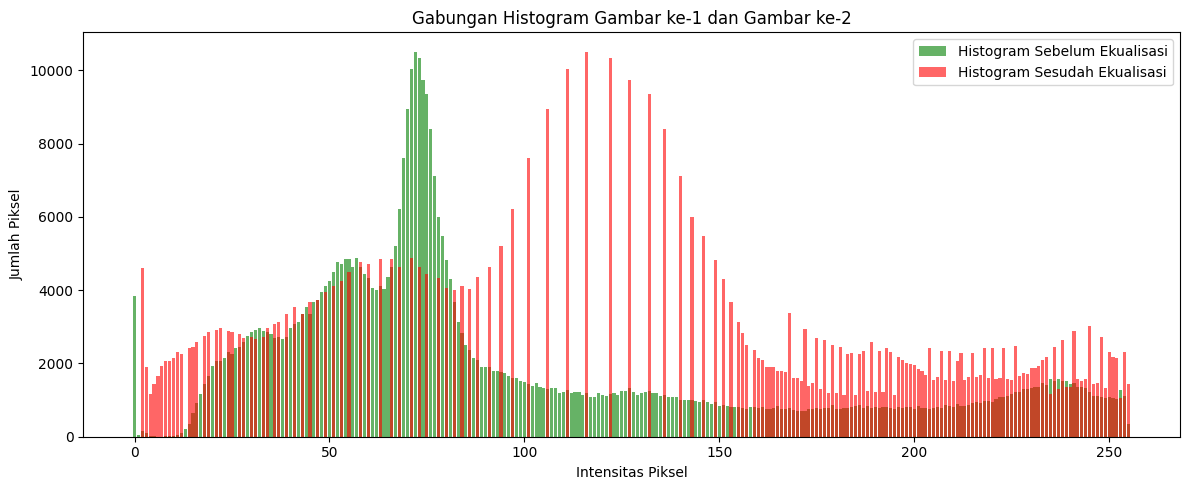

In [ ]:
hist_sebelum = np.zeros(256, dtype=int)
for y in range(gray.shape[0]):
    for x in range(gray.shape[1]):
        hist_sebelum[int(gray[y][x])] += 1

hist_sesudah = np.zeros(256, dtype=int)
for y in range(hasil_ekualisasi.shape[0]):
    for x in range(hasil_ekualisasi.shape[1]):
        hist_sesudah[int(hasil_ekualisasi[y][x])] += 1
        
plt.figure(figsize=(12, 5))

plt.bar(range(256), hist_sebelum, color='green', alpha=0.6, label='Histogram Sebelum Ekualisasi')
plt.bar(range(256), hist_sesudah, color='red',   alpha=0.6, label='Histogram Sesudah Ekualisasi')

plt.title('Gabungan Histogram Gambar ke-1 dan Gambar ke-2')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.legend()
plt.tight_layout()
plt.show()

## HISTOGRAM WINDUT DAN BUNGA

Kode diawali dengan membaca dua gambar, yaitu `Windut.png` dan `Bunga.png`. Kedua citra kemudian diubah menjadi grayscale menggunakan `cv2.cvtColor()` agar proses histogram lebih mudah dilakukan.

Nilai piksel dikonversi ke rentang 0–255 menggunakan `np.clip()` dan diubah ke tipe data `uint8`.

Histogram masing-masing citra dihitung secara manual menggunakan perulangan `for` dengan menghitung jumlah kemunculan setiap intensitas piksel.

- `hist_windut` menyimpan histogram citra Windut.
- `hist_bunga` menyimpan histogram citra Bunga.

Hasil histogram kemudian ditampilkan menggunakan diagram batang (`plt.bar()`) agar distribusi intensitas kedua citra dapat dibandingkan.

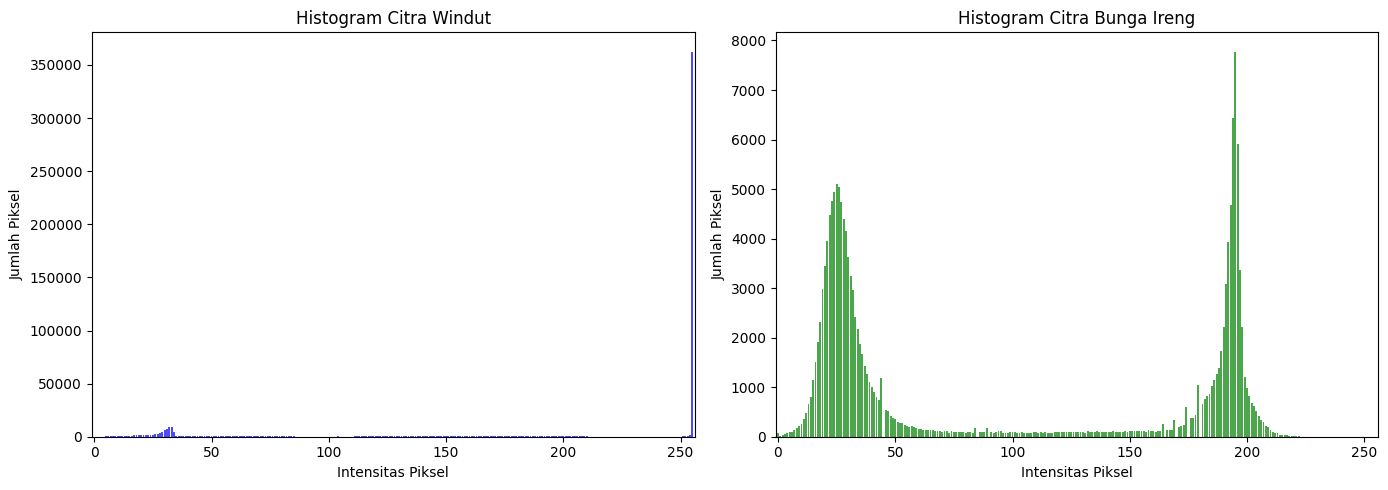

In [ ]:
Windut = plt.imread("Assets/Windut.png")
Bunga  = plt.imread("Assets/Bunga.png")

gray_windut = cv2.cvtColor(Windut.astype('float32'), cv2.COLOR_RGB2GRAY)
gray_windut = np.clip(gray_windut * 255, 0, 255).astype(np.uint8)

gray_bunga  = cv2.cvtColor(Bunga.astype('float32'), cv2.COLOR_RGB2GRAY)
gray_bunga  = np.clip(gray_bunga * 255, 0, 255).astype(np.uint8)

hist_windut = np.zeros(256, dtype=int)
for y in range(gray_windut.shape[0]):
    for x in range(gray_windut.shape[1]):
        hist_windut[gray_windut[y][x]] += 1

hist_bunga = np.zeros(256, dtype=int)
for y in range(gray_bunga.shape[0]):
    for x in range(gray_bunga.shape[1]):
        hist_bunga[gray_bunga[y][x]] += 1

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.bar(range(256), hist_windut, color='blue', alpha=0.7)
plt.title('Histogram Citra Windut')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim(-1, 256)

plt.subplot(1, 2, 2)
plt.bar(range(256), hist_bunga, color='green', alpha=0.7)
plt.title('Histogram Citra Bunga Ireng')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim(-1, 256)

plt.tight_layout()
plt.show()

## SPESIFIKASI WINDUT

Kode digunakan untuk melakukan histogram specification atau histogram matching antara citra Windut dan citra Bunga.

Langkah pertama adalah menghitung nilai Cumulative Distribution Function (CDF) dari masing-masing histogram citra. Setelah itu, CDF dinormalisasi ke rentang 0–255.

Selanjutnya dibuat `lookup table` untuk mencari nilai intensitas pada citra Bunga yang paling mendekati nilai CDF citra Windut. Proses ini dilakukan dengan membandingkan selisih antar nilai CDF.

Array `lookup` kemudian digunakan untuk mengganti setiap nilai piksel pada citra Windut sehingga distribusi histogramnya mengikuti citra Bunga.

Hasil akhir histogram specification ditampilkan dalam bentuk citra grayscale menggunakan `plt.imshow()`.

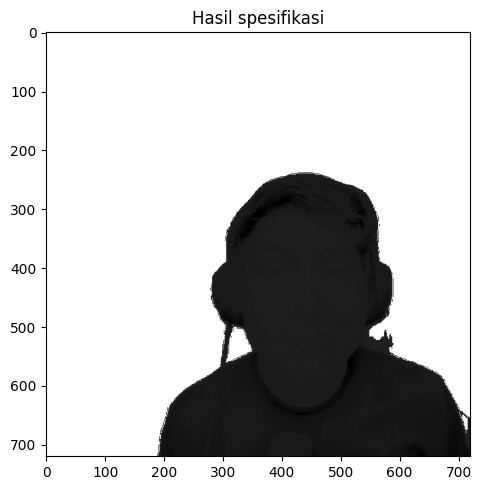

In [ ]:
cdf_windut = np.zeros(256, dtype=int)
cdf_windut[0] = hist_windut[0]
for i in range(1, 256):
    cdf_windut[i] = cdf_windut[i-1] + hist_windut[i]

total_windut = gray_windut.shape[0] * gray_windut.shape[1]

cdf_windut_norm = np.zeros(256, dtype=int)
for i in range(256):
    cdf_windut_norm[i] = int(np.round(cdf_windut[i] * 255 / total_windut))

cdf_bunga = np.zeros(256, dtype=int)
cdf_bunga[0] = hist_bunga[0]
for i in range(1, 256):
    cdf_bunga[i] = cdf_bunga[i-1] + hist_bunga[i]

total_bunga = gray_bunga.shape[0] * gray_bunga.shape[1]

cdf_bunga_norm = np.zeros(256, dtype=int)
for i in range(256):
    cdf_bunga_norm[i] = int(np.round(cdf_bunga[i] * 255 / total_bunga))

lookup = np.zeros(256, dtype=int)

gelap = 0

for i in range(256):
    target      = cdf_windut_norm[i]
    selisih_min = 999
    j_terbaik   = 0
    for j in range(256):
        selisih = abs(cdf_bunga_norm[j] - target)
        if selisih < selisih_min:
            selisih_min = selisih
            j_terbaik   = j
    hasil = j_terbaik - gelap
    if hasil < 0:
        hasil = 0
    lookup[i] = hasil

height, width = gray_windut.shape
hasil_spesifikasi = np.zeros((height, width), dtype=int)

for y in range(height):
    for x in range(width):
        hasil_spesifikasi[y][x] = lookup[gray_windut[y][x]]

plt.figure(figsize=(14, 5))

plt.imshow(hasil_spesifikasi, cmap='gray')
plt.axis('on')

plt.tight_layout()
plt.show()

## HISTOGRAM HASIL SPESIFIKASI

Kode digunakan untuk menghitung histogram dari citra hasil histogram specification.

Perhitungan dilakukan secara manual menggunakan perulangan `for` dengan menghitung jumlah setiap intensitas piksel pada citra `hasil_spesifikasi`.

Histogram kemudian ditampilkan menggunakan diagram batang (`plt.bar()`) untuk melihat distribusi intensitas piksel setelah proses spesifikasi histogram dilakukan.

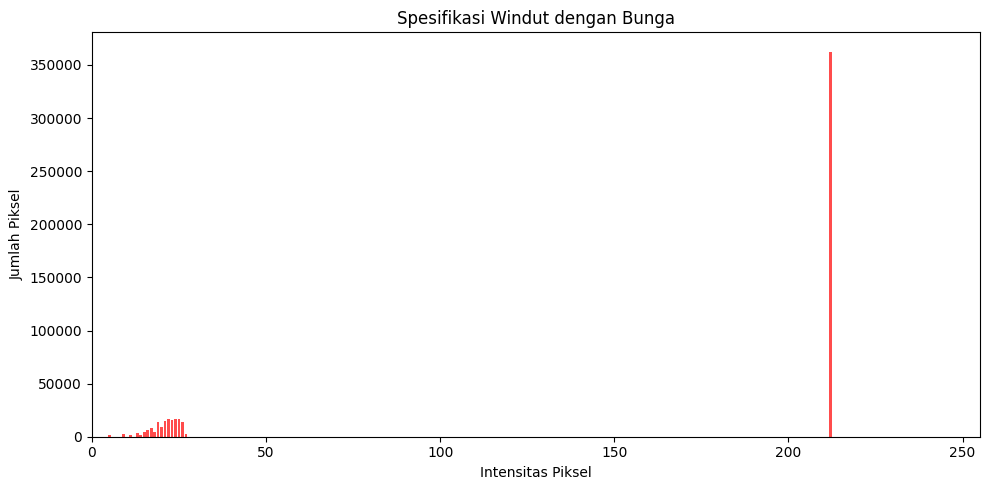

In [97]:
hist_spesifikasi = np.zeros(256, dtype=int)
for y in range(hasil_spesifikasi.shape[0]):
    for x in range(hasil_spesifikasi.shape[1]):
        hist_spesifikasi[hasil_spesifikasi[y][x]] += 1

plt.figure(figsize=(10, 5))

plt.bar(range(256), hist_spesifikasi, color='red', alpha=0.7)

plt.title('Spesifikasi Windut dengan Bunga')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim(0, 255)
plt.tight_layout()
plt.show()

## MASKING CITRA

Kode digunakan untuk menggabungkan dua citra hasil pengolahan, yaitu citra hasil spesifikasi histogram dan citra hasil ekualisasi.

Ukuran kedua citra terlebih dahulu disesuaikan menggunakan nilai tinggi dan lebar terkecil agar proses masking dapat dilakukan tanpa error.

Variabel `threshold` digunakan sebagai batas intensitas piksel. Proses masking dilakukan menggunakan perulangan `for`:

- jika nilai piksel pada citra spesifikasi lebih kecil dari threshold, maka nilai piksel tersebut digunakan,
- jika tidak, maka digunakan nilai piksel dari citra hasil ekualisasi.

Hasil akhir masking disimpan pada array `hasil_mask` dan ditampilkan dalam bentuk citra grayscale.

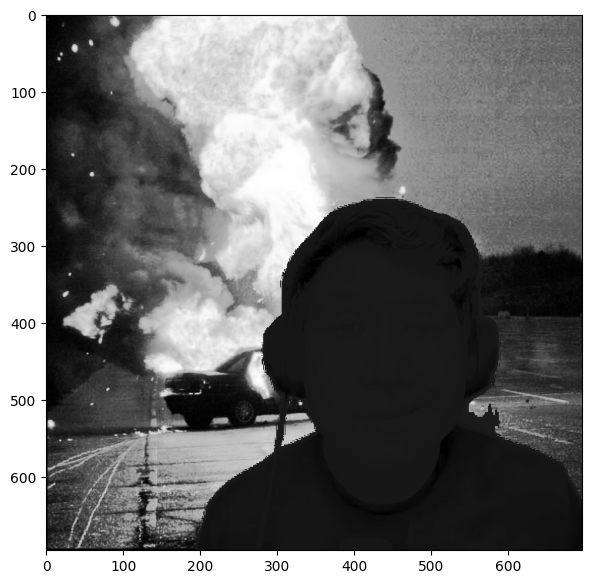

In [98]:
h1, w1 = hasil_spesifikasi.shape
h2, w2 = hasil_ekualisasi.shape

h_min = min(h1, h2)
w_min = min(w1, w2)

spesifikasi_crop = hasil_spesifikasi[:h_min, :w_min]
meledak_crop     = hasil_ekualisasi[:h_min, :w_min]

threshold = 50

hasil_mask = np.zeros((h_min, w_min), dtype=np.uint8)

for y in range(h_min):
    for x in range(w_min):
        if spesifikasi_crop[y][x] < threshold:
            hasil_mask[y][x] = spesifikasi_crop[y][x]
        else:
            hasil_mask[y][x] = int(meledak_crop[y][x])

plt.figure(figsize=(6, 6))
plt.imshow(hasil_mask, cmap='gray')
plt.axis('on')
plt.tight_layout()
plt.show()

## GABUNG CITRA DENGAN TRESHOLD

Kode digunakan untuk menggabungkan citra grayscale Windut dengan citra hasil ekualisasi berdasarkan nilai threshold tertentu.

Ukuran kedua citra terlebih dahulu disamakan menggunakan tinggi dan lebar minimum agar proses penggabungan dapat dilakukan dengan aman.

Citra hasil ekualisasi dijadikan dasar pada variabel `gabung_akhir`. Selanjutnya dilakukan pengecekan nilai piksel pada citra hasil spesifikasi:

- jika nilai piksel lebih kecil dari `threshold`, maka piksel dari citra Windut digunakan,
- jika tidak, maka piksel dari citra hasil ekualisasi tetap dipertahankan.

Hasil akhir penggabungan kemudian ditampilkan dalam bentuk citra grayscale.

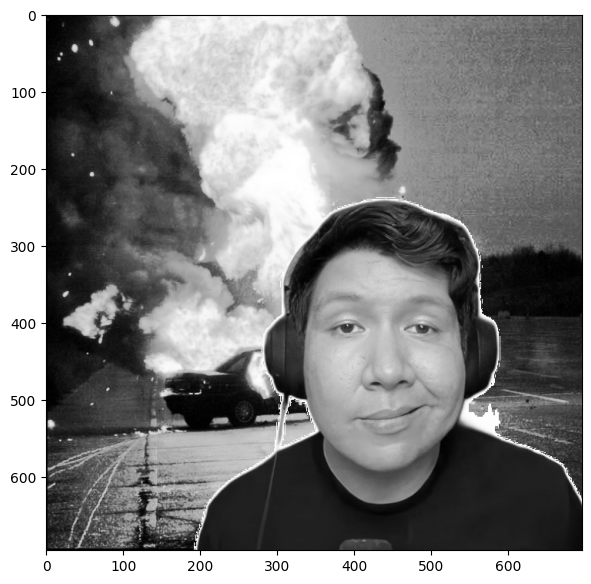

In [ ]:
h1, w1 = gray_windut.shape
h2, w2 = hasil_ekualisasi.shape

h_min = min(h1, h2)
w_min = min(w1, w2)

windut_crop      = gray_windut[:h_min, :w_min]
spesifikasi_crop = hasil_spesifikasi[:h_min, :w_min]
meledak_crop     = hasil_ekualisasi[:h_min, :w_min]

gabung_akhir = meledak_crop.copy()

threshold = 200

for y in range(h_min):
    for x in range(w_min):
        if spesifikasi_crop[y][x] < threshold:
            gabung_akhir[y][x] = windut_crop[y][x]

plt.figure(figsize=(6, 6))
plt.imshow(gabung_akhir, cmap='gray')
plt.axis('on')
plt.tight_layout()
plt.show()

## SPESIFIKASI 2

Kode diawali dengan membaca gambar `Langit.png` kemudian mengubahnya menjadi citra grayscale. Setelah itu dilakukan perhitungan histogram dan CDF secara manual untuk mendapatkan distribusi intensitas piksel citra Langit.

Proses yang sama juga dilakukan pada citra `gabung_akhir` untuk memperoleh histogram dan CDF citra tersebut.

Selanjutnya dibuat `lookup table` untuk melakukan histogram specification, yaitu menyesuaikan distribusi histogram citra `gabung_akhir` agar menyerupai distribusi histogram citra Langit.

Hasil spesifikasi disimpan pada variabel `hasil_akhir`.

Setelah proses spesifikasi selesai, dilakukan blending antara `hasil_akhir` dan `gabung_akhir` menggunakan parameter `alpha`. Teknik blending digunakan untuk menggabungkan kedua citra sehingga menghasilkan tampilan yang lebih halus dan natural.

Hasil akhir blending kemudian ditampilkan dalam bentuk citra grayscale.

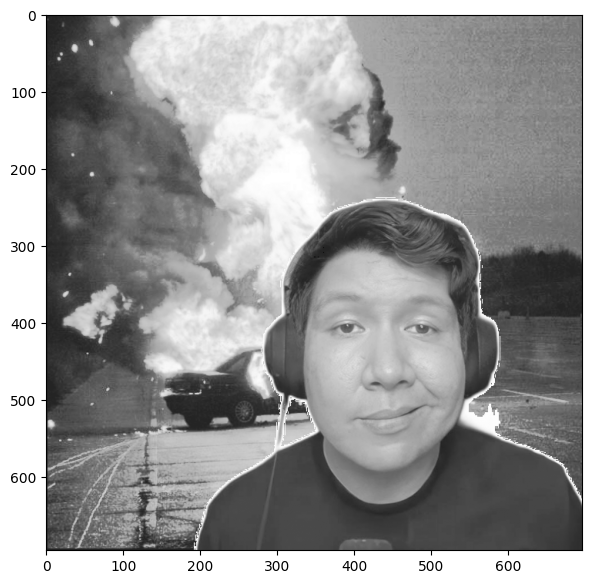

In [ ]:
Langit = plt.imread("Assets/Langit.png")

gray_langit = cv2.cvtColor(Langit.astype('float32'), cv2.COLOR_RGB2GRAY)
gray_langit = gray_langit * 255

h_l, w_l = gray_langit.shape
hist_langit = np.zeros(256, dtype=int)
for y in range(h_l):
    for x in range(w_l):
        hist_langit[int(gray_langit[y][x])] += 1

cdf_langit = np.zeros(256, dtype=int)
cdf_langit[0] = hist_langit[0]
for i in range(1, 256):
    cdf_langit[i] = cdf_langit[i-1] + hist_langit[i]

total_langit = h_l * w_l
cdf_langit_norm = np.zeros(256, dtype=int)
for i in range(256):
    cdf_langit_norm[i] = int(np.round(cdf_langit[i] * 255 / total_langit))

h_g, w_g = gabung_akhir.shape
hist_gabung = np.zeros(256, dtype=int)
for y in range(h_g):
    for x in range(w_g):
        hist_gabung[int(gabung_akhir[y][x])] += 1

cdf_gabung = np.zeros(256, dtype=int)
cdf_gabung[0] = hist_gabung[0]
for i in range(1, 256):
    cdf_gabung[i] = cdf_gabung[i-1] + hist_gabung[i]

total_gabung = h_g * w_g
cdf_gabung_norm = np.zeros(256, dtype=int)
for i in range(256):
    cdf_gabung_norm[i] = int(np.round(cdf_gabung[i] * 255 / total_gabung))

lookup_akhir = np.zeros(256, dtype=int)
for i in range(256):
    target      = cdf_gabung_norm[i]
    selisih_min = 999
    j_terbaik   = 0
    for j in range(256):
        selisih = abs(cdf_langit_norm[j] - target)
        if selisih < selisih_min:
            selisih_min = selisih
            j_terbaik   = j
    lookup_akhir[i] = j_terbaik

hasil_akhir = np.zeros((h_g, w_g), dtype=int)
for y in range(h_g):
    for x in range(w_g):
        hasil_akhir[y][x] = lookup_akhir[int(gabung_akhir[y][x])]

alpha = 0.4

hasil_blend = np.zeros((h_g, w_g), dtype=int)
for y in range(h_g):
    for x in range(w_g):
        hasil_blend[y][x] = int(np.round(
            alpha * hasil_akhir[y][x] + (1 - alpha) * gabung_akhir[y][x]
        ))

plt.figure(figsize=(6, 6))
plt.imshow(hasil_blend, cmap='gray')
plt.axis('on')
plt.tight_layout()
plt.show()

## HASIL HISTOGRAM

Kode digunakan untuk menghitung histogram dari citra hasil blending yang disimpan pada variabel `hasil_blend`.

Perhitungan histogram dilakukan secara manual menggunakan perulangan `for` dengan menghitung jumlah kemunculan setiap intensitas piksel.

Histogram kemudian divisualisasikan menggunakan diagram batang (`plt.bar()`) untuk melihat distribusi intensitas piksel pada citra hasil akhir setelah proses histogram specification dan blending dilakukan.

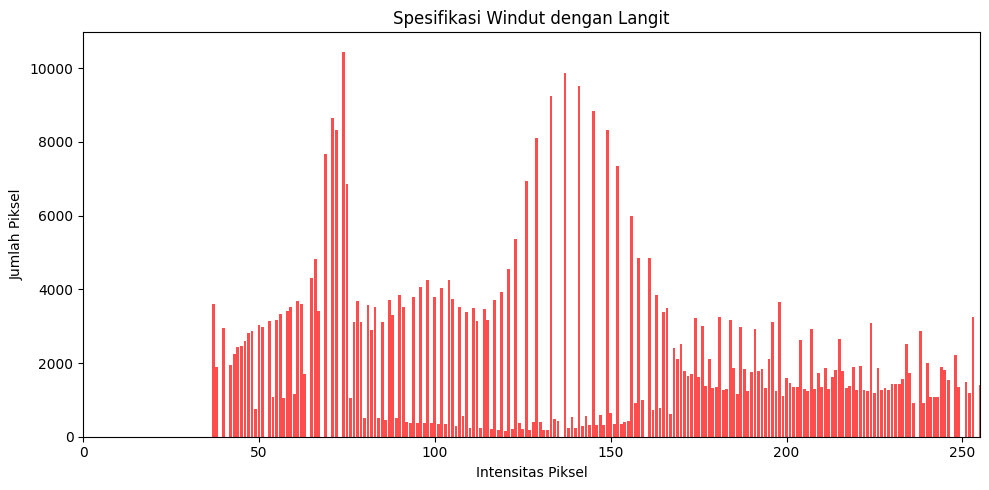

In [ ]:
hist_blend = np.zeros(256, dtype=int)
for y in range(h_g):
    for x in range(w_g):
        hist_blend[int(hasil_blend[y][x])] += 1

plt.figure(figsize=(10, 5))
plt.bar(range(256), hist_blend, color='red', alpha=0.7)
plt.title('Spesifikasi Windut dengan Langit')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim(0, 255)
plt.tight_layout()
plt.show()

## CITRA BERWARNA

Kode digunakan untuk menggabungkan dua citra berwarna, yaitu citra Windut dan citra hasil gabungan sebelumnya (`gabung`).

Ukuran kedua citra terlebih dahulu disesuaikan menggunakan tinggi dan lebar minimum agar proses penggabungan dapat dilakukan tanpa error.

Array kosong `gabung_color` dibuat untuk menyimpan hasil penggabungan citra RGB.

Proses penggabungan dilakukan menggunakan threshold pada citra `spesifikasi_crop`:

- jika nilai piksel lebih kecil dari threshold, maka warna diambil dari citra Windut,
- jika tidak, maka warna diambil dari citra Meledak.

Pada proses ini dilakukan pertukaran urutan channel warna merah dan biru agar tampilan warna citra tetap sesuai saat ditampilkan.

Hasil akhir penggabungan citra berwarna kemudian ditampilkan menggunakan `plt.imshow()`.

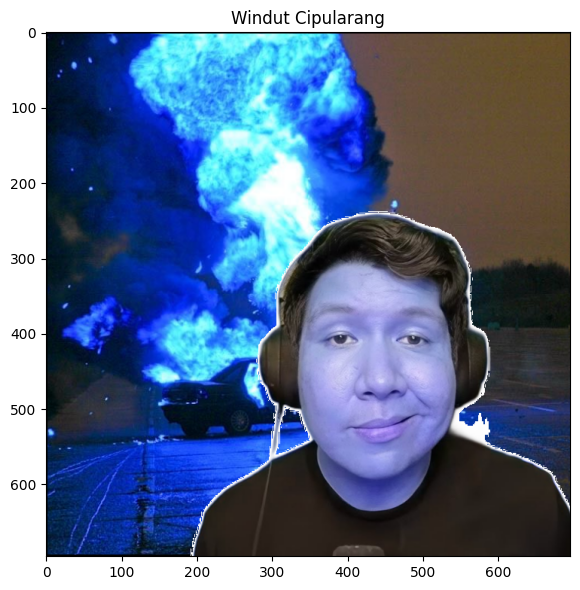

In [ ]:
Windut_color  = plt.imread("Assets/Windut.png")
Meledak_color = gabung

h1, w1, _ = Windut_color.shape
h2, w2, _ = Meledak_color.shape

h_min = min(h1, h2)
w_min = min(w1, w2)

windut_color_crop  = Windut_color[:h_min, :w_min]
meledak_color_crop = Meledak_color[:h_min, :w_min]
spesifikasi_crop   = hasil_spesifikasi[:h_min, :w_min]

gabung_color = np.zeros((h_min, w_min, 3))

threshold = 200

for y in range(h_min):
    for x in range(w_min):
        if spesifikasi_crop[y][x] < threshold:
            gabung_color[y][x][0] = windut_color_crop[y][x][2]
            gabung_color[y][x][1] = windut_color_crop[y][x][1]
            gabung_color[y][x][2] = windut_color_crop[y][x][0]
        else:
            gabung_color[y][x][0] = meledak_color_crop[y][x][2]
            gabung_color[y][x][1] = meledak_color_crop[y][x][1]
            gabung_color[y][x][2] = meledak_color_crop[y][x][0]

plt.figure(figsize=(6, 6))
plt.imshow(gabung_color)
plt.axis('on')
plt.title('Windut Cipularang')
plt.tight_layout()
plt.show()